<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Data Preprocessing and Feature Engineering

*Session 5 · Notebook 01.03 · Lecture · Coach version · Databricks (no extra installs)*

## Overview

Before any model can learn, the data has to be prepared. This notebook covers the core preprocessing steps in scikit-learn: handling missing values (numeric and categorical), scaling (normalization and standardization), engineering new features, encoding categorical variables, dealing with class imbalance, and splitting the data so that preprocessing does not leak information from the test set. It finishes with the professional way to wire all of this together, a scikit-learn **Pipeline**.

The running example is the **German Credit** dataset (a risk dataset), with a small synthetic table for the missing-data and date sections. The exercises use the seaborn **tips** dataset.

## Learning Objectives

By the end of this notebook you will be able to:

- Impute missing values for both numeric and categorical columns with `SimpleImputer`.
- Scale features with `MinMaxScaler` and `StandardScaler`, and see the impact visually.
- Engineer new features (date parts, bins, ratios and interactions).
- Encode categorical variables with label and one-hot encoding.
- Rebalance an imbalanced target with over- and under-sampling.
- Split data and preprocess without leakage, and assemble a `Pipeline`.

## Prerequisites

- Session 4 (distributions, skew, outliers, missing-data mechanisms).
- Session 2/3 pandas (`read_csv`, `isna`, selecting columns).

## Index

1. [Why this matters for risk modelling](#sec1)
2. [Handling missing data (numeric and categorical)](#sec2)
3. [Normalization (Min-Max scaling)](#sec3)
4. [Standardization (Z-scaling)](#sec4)
5. [Feature engineering](#sec5)
6. [Encoding categorical variables](#sec6)
7. [Handling imbalanced data](#sec7)
8. [Splitting and preprocessing without leakage](#sec8)
9. [Putting it together: a preprocessing Pipeline](#sec9)
10. [Exercises](#exercises)
11. [Challenge](#challenge)
12. [Key Takeaways](#takeaways)
13. [Further Reading](#reading)

<a id="setup"></a>
# Section 0: Setup

The running example dataset is `german_credit.csv` (1,000 loan applicants with an imbalanced good/bad target), read from the repo-root `datasets/` folder (two levels up). The exercises use the seaborn `tips` dataset. A small synthetic table is built in Section 2. This is the **Databricks** variant: it uses only the pre-installed stack, so class rebalancing uses `sklearn.utils.resample` instead of `imbalanced-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Or read directly from the public S3 bucket (no local file needed):
# credit = pd.read_csv('https://rockborne-bucket-01-cbs.s3.eu-west-2.amazonaws.com/Data_Sources_CBS_Risk/Session_5/german_credit.csv')   # running example
# ...or read the paths from a config file (the local read below stays the default):
# from config import session_datasets_http
# credit = pd.read_csv(session_datasets_http["german_credit"])   # running example
# Or from S3 with Spark, then to pandas (needs a SparkSession, e.g. on Databricks):
# credit = spark.read.csv("s3://rockborne-bucket-01-cbs/Data_Sources_CBS_Risk/Session_5/german_credit.csv", header=True, inferSchema=True).toPandas()   # running example
credit = pd.read_csv('../../datasets/Session_5/german_credit.csv')   # running example
# Seaborn source (kept for reuse with other clients); to use it, swap the read_csv line for:
# tips = sns.load_dataset('tips')                             # used in the exercises
# Or read directly from the public S3 bucket (no local file needed):
# tips = pd.read_csv('https://rockborne-bucket-01-cbs.s3.eu-west-2.amazonaws.com/Data_Sources_CBS_Risk/Session_5/tips.csv')                             # used in the exercises
# ...or read the paths from a config file (the local read below stays the default):
# from config import session_datasets_http
# tips = pd.read_csv(session_datasets_http["tips"])                             # used in the exercises
# Or from S3 with Spark, then to pandas (needs a SparkSession, e.g. on Databricks):
# tips = spark.read.csv("s3://rockborne-bucket-01-cbs/Data_Sources_CBS_Risk/Session_5/tips.csv", header=True, inferSchema=True).toPandas()                             # used in the exercises
tips = pd.read_csv('../../datasets/Session_5/tips.csv')                             # used in the exercises
print('german_credit:', credit.shape, '| tips:', tips.shape)
credit.head()

german_credit: (1000, 21) | tips: (244, 7)


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,risk
0,< 0 DM,6,critical/other credits,radio/TV,1169,unknown/none,>= 7 yrs,4,male single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,good
1,0-200 DM,48,existing paid duly,radio/TV,5951,< 100 DM,1-4 yrs,2,female div/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,bad
2,no account,12,critical/other credits,education,2096,< 100 DM,4-7 yrs,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,< 0 DM,42,existing paid duly,furniture/equipment,7882,< 100 DM,4-7 yrs,2,male single,guarantor,...,savings/insurance,45,none,for free,1,skilled employee,2,none,yes,good
4,< 0 DM,24,past delays,car (new),4870,< 100 DM,1-4 yrs,3,male single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,bad


<a id="sec1"></a>
# Section 1: Why this matters for risk modelling

A credit or fraud model is only as good as the data fed into it, and raw risk data is rarely model-ready.

| Preprocessing step | Why a risk model needs it |
|---|---|
| **Missing values** | Application data has gaps, in text fields as well as numbers; most models cannot train with `NaN`. |
| **Scaling** | Distance- and gradient-based models (KNN, SVM, regularised regression) are distorted when amount is in thousands and age in tens. |
| **Feature engineering** | A ratio like instalment-to-income often predicts default better than either raw column. |
| **Encoding** | Models need numbers, but categories like loan purpose have no natural order. |
| **Class imbalance** | Defaults and fraud are rare; without rebalancing a model can score everyone 'good' and still look accurate. |
| **No leakage** | If scaling or resampling sees the test set, validation results are optimistic and the model fails in production. |

Getting preprocessing wrong does not throw an error; it silently produces a model that looks fine in testing and misbehaves in production.

<a id="sec2"></a>
# Section 2: Handling missing data (numeric and categorical)

**Definition:** imputation replaces missing values with estimates so the data is complete enough to model (the statistical side, and the MCAR/MAR/MNAR mechanisms, were covered in Session 4).

**Example:** an application form left the income field blank (numeric) and the region field blank (categorical); we fill each appropriately.

**Analogy:** filling gaps in a form with the typical answer so the form can be processed.

**Explanation:** `SimpleImputer` fills a column with a statistic. For **numeric** columns use the **mean** (or median for skewed money columns); for **categorical** columns you cannot take a mean, so use the **most frequent** value. We use a small synthetic customer table that has gaps in both kinds of column (and a date column we reuse in Section 5).

In [2]:
# A small synthetic dataset with missing values in numeric AND categorical columns
synth = pd.DataFrame({
    'region':      ['North', 'South', np.nan, 'East', 'West', 'North', np.nan, 'South', 'East', 'West'],
    'age':         [34, 45, 29, np.nan, 52, 41, 38, np.nan, 27, 60],
    'income':      [42000, 58000, np.nan, 61000, 73000, np.nan, 52000, 48000, 39000, 85000],
    'signup_date': pd.to_datetime(['2021-01-15', '2021-03-22', '2021-07-01', '2022-02-10',
                                   '2022-05-30', '2022-08-19', '2023-01-05', '2023-04-12',
                                   '2023-09-27', '2023-12-03']),
    'subscribed':  ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes'],
})
print('Missing values per column:')
print(synth.isna().sum())
synth

Missing values per column:
region         2
age            2
income         2
signup_date    0
subscribed     0
dtype: int64


,region,age,income,signup_date,subscribed
0,North,34.0,42000.0,2021-01-15,Yes
1,South,45.0,58000.0,2021-03-22,No
2,NaN,29.0,NaN,2021-07-01,Yes
3,East,NaN,61000.0,2022-02-10,No
4,West,52.0,73000.0,2022-05-30,Yes
5,North,41.0,NaN,2022-08-19,No
6,NaN,38.0,52000.0,2023-01-05,Yes
7,South,NaN,48000.0,2023-04-12,No
8,East,27.0,39000.0,2023-09-27,No
9,West,60.0,85000.0,2023-12-03,Yes


### Impute numeric columns with the mean

In [3]:
from sklearn.impute import SimpleImputer

num_cols = ['age', 'income']
num_imputer = SimpleImputer(strategy='mean')      # 'median' is safer for skewed money data
synth[num_cols] = num_imputer.fit_transform(synth[num_cols])
synth[num_cols]

,age,income
0,34.00,42000.0
1,45.00,58000.0
2,29.00,57250.0
3,40.75,61000.0
4,52.00,73000.0
5,41.00,57250.0
6,38.00,52000.0
7,40.75,48000.0
8,27.00,39000.0
9,60.00,85000.0


### Impute categorical columns with the most frequent value

A category has no mean, so we fill blanks with the **mode** (`strategy='most_frequent'`).

In [4]:
cat_cols = ['region']
cat_imputer = SimpleImputer(strategy='most_frequent')
synth[cat_cols] = cat_imputer.fit_transform(synth[cat_cols])
print('Missing after imputation:', int(synth.isna().sum().sum()))
synth

Missing after imputation: 0


,region,age,income,signup_date,subscribed
0,North,34.00,42000.0,2021-01-15,Yes
1,South,45.00,58000.0,2021-03-22,No
2,East,29.00,57250.0,2021-07-01,Yes
3,East,40.75,61000.0,2022-02-10,No
4,West,52.00,73000.0,2022-05-30,Yes
5,North,41.00,57250.0,2022-08-19,No
6,East,38.00,52000.0,2023-01-05,Yes
7,South,40.75,48000.0,2023-04-12,No
8,East,27.00,39000.0,2023-09-27,No
9,West,60.00,85000.0,2023-12-03,Yes


<a id="sec3"></a>
# Section 3: Normalization (Min-Max scaling)

**Definition:** normalization rescales each feature to a fixed range, usually 0 to 1.

**Example:** putting `credit_amount` (thousands), `duration_months` (tens) and `age_years` (tens) onto the same 0-to-1 scale.

**Analogy:** redrawing several charts so they all use the same axis, making them comparable.

**Explanation:** `MinMaxScaler` maps the smallest value to 0 and the largest to 1. It keeps the shape of the distribution and is useful when a model expects bounded inputs, but it is sensitive to outliers. The plot below shows the impact: before scaling, `credit_amount` dwarfs the other features; after, all three are comparable.

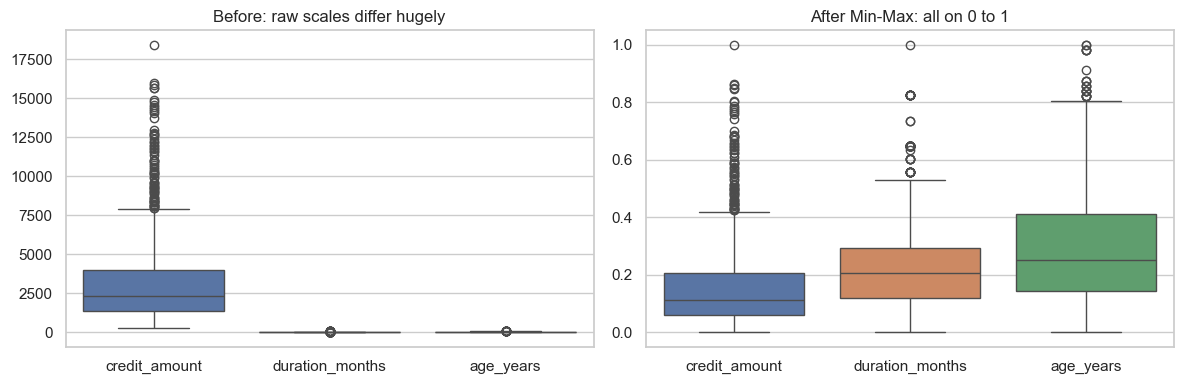

,credit_amount,duration_months,age_years
count,1000.00,1000.00,1000.00
mean,0.17,0.25,0.30
std,0.16,0.18,0.20
min,0.00,0.00,0.00
25%,0.06,0.12,0.14
50%,0.11,0.21,0.25
75%,0.20,0.29,0.41
max,1.00,1.00,1.00


In [5]:
from sklearn.preprocessing import MinMaxScaler

num = credit[['credit_amount', 'duration_months', 'age_years']]
num_norm = pd.DataFrame(MinMaxScaler().fit_transform(num), columns=num.columns)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=num, ax=ax[0]); ax[0].set_title('Before: raw scales differ hugely')
sns.boxplot(data=num_norm, ax=ax[1]); ax[1].set_title('After Min-Max: all on 0 to 1')
plt.tight_layout(); plt.show()
num_norm.describe().round(2)

### The shape is unchanged, only the axis

Scaling relabels the axis; it does not change the **shape** of the distribution. Here is `age_years` as a histogram with a KDE curve, before and after Min-Max scaling: the curve is the same, only the x-axis numbers differ (now 0 to 1).

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(num['age_years'], kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('age_years before (raw scale, years)')
sns.histplot(num_norm['age_years'], kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('age_years after Min-Max (0 to 1)')
plt.tight_layout(); plt.show()

<a id="sec4"></a>
# Section 4: Standardization (Z-scaling)

**Definition:** standardization rescales each feature to mean 0 and standard deviation 1 (a z-score).

**Example:** expressing each credit amount as 'how many standard deviations from the average'.

**Analogy:** grading on a curve: every subject is expressed relative to its own average and spread, so they can be compared fairly.

**Explanation:** `StandardScaler` is the default for most models (regularised regression, SVM, PCA) because it centres the data and equalises variance. Use standardization by default; reach for normalization when a method needs a fixed input range. The plot shows every feature now centred on 0 with comparable spread.

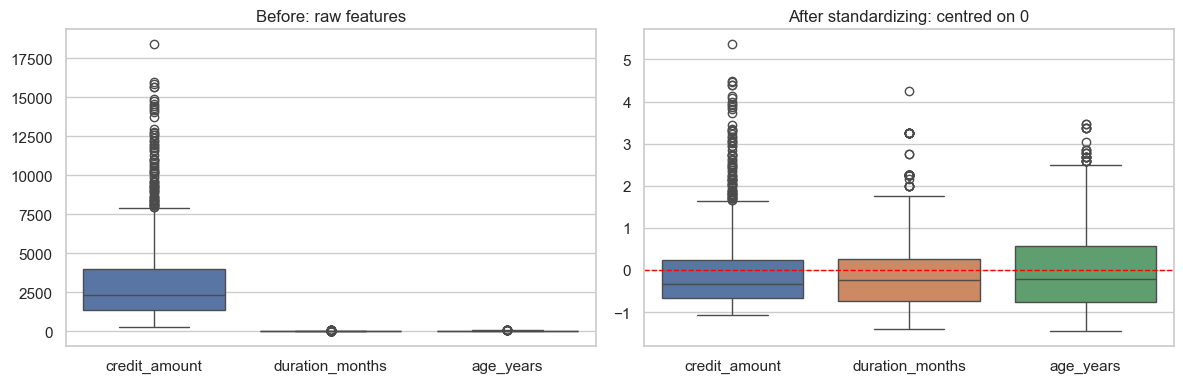

Means (~0): [0.0, 0.0, 0.0]


In [6]:
from sklearn.preprocessing import StandardScaler

num_std = pd.DataFrame(StandardScaler().fit_transform(num), columns=num.columns)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=num, ax=ax[0]); ax[0].set_title('Before: raw features')
sns.boxplot(data=num_std, ax=ax[1]); ax[1].set_title('After standardizing: centred on 0')
ax[1].axhline(0, color='red', ls='--', lw=1)
plt.tight_layout(); plt.show()
print('Means (~0):', num_std.mean().round(3).tolist())

### Again, the shape is preserved

Standardizing re-centres and rescales the axis but keeps the shape. Below is `age_years` before and after: the same curve, but the x-axis is now measured in standard deviations around 0.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(num['age_years'], kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('age_years before (raw scale, years)')
sns.histplot(num_std['age_years'], kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('age_years after standardizing (mean 0, sd 1)')
plt.tight_layout(); plt.show()

### Try it yourself

Standardize the credit `installment_rate` and `existing_credits` columns with `StandardScaler`, and confirm each has mean about 0.

In [7]:
# Your turn. Write your solution here:


In [8]:
# Coach answer
cols = ['installment_rate', 'existing_credits']
scaled = StandardScaler().fit_transform(credit[cols])
print('Means:', scaled.mean(axis=0).round(3))

Means: [ 0. -0.]


<a id="sec5"></a>
# Section 5: Feature engineering

**Definition:** feature engineering creates new, more informative columns from existing ones.

**Example:** turning a signup date into a customer tenure, or `credit_amount` and `duration_months` into a monthly-instalment estimate.

**Analogy:** a chef combining raw ingredients into a dish: the combination is worth more than the parts.

**Explanation:** good features often matter more than the choice of model. Three common techniques: extracting parts of a date, binning a continuous variable, and building ratios or interactions.

### 5.1 Extracting parts of a date

Using the synthetic table's `signup_date`, we pull out calendar parts and derive a tenure (days since signup), which is often more predictive than the raw date.

In [9]:
synth['signup_year'] = synth['signup_date'].dt.year
synth['signup_month'] = synth['signup_date'].dt.month
synth['signup_day_of_week'] = synth['signup_date'].dt.day_name()
synth['tenure_days'] = (pd.Timestamp('2024-01-01') - synth['signup_date']).dt.days
synth[['signup_date', 'signup_year', 'signup_month', 'signup_day_of_week', 'tenure_days']]

,signup_date,signup_year,signup_month,signup_day_of_week,tenure_days
0,2021-01-15,2021,1,Friday,1081
1,2021-03-22,2021,3,Monday,1015
2,2021-07-01,2021,7,Thursday,914
3,2022-02-10,2022,2,Thursday,690
4,2022-05-30,2022,5,Monday,581
5,2022-08-19,2022,8,Friday,500
6,2023-01-05,2023,1,Thursday,361
7,2023-04-12,2023,4,Wednesday,264
8,2023-09-27,2023,9,Wednesday,96
9,2023-12-03,2023,12,Sunday,29


### 5.2 Binning a continuous variable

`pd.cut` groups a numeric column into labelled bands, which can capture non-linear effects (risk that differs by age band rather than smoothly with age).

In [10]:
credit['age_band'] = pd.cut(credit['age_years'], bins=[18, 25, 35, 50, 75],
                            labels=['18-25', '26-35', '36-50', '51+'])
credit['age_band'].value_counts().sort_index()

age_band
18-25    190
26-35    398
36-50    299
51+      113
Name: count, dtype: int64

### 5.3 Ratios and interactions

Combining columns often creates the most predictive feature. Here, an estimated monthly instalment (amount divided by duration) captures repayment burden.

In [11]:
credit['monthly_instalment'] = (credit['credit_amount'] / credit['duration_months']).round(1)
credit[['credit_amount', 'duration_months', 'monthly_instalment']].head()

,credit_amount,duration_months,monthly_instalment
0,1169,6,194.8
1,5951,48,124.0
2,2096,12,174.7
3,7882,42,187.7
4,4870,24,202.9


### Try it yourself

Create a feature `amount_per_year_of_age` = `credit_amount` divided by `age_years` and print its first few values.

In [12]:
# Your turn. Write your solution here:


In [13]:
# Coach answer
credit['amount_per_year_of_age'] = (credit['credit_amount'] / credit['age_years']).round(1)
print(credit['amount_per_year_of_age'].head().tolist())

[17.4, 270.5, 42.8, 175.2, 91.9]


<a id="sec6"></a>
# Section 6: Encoding categorical variables

**Definition:** encoding converts categorical text into numbers a model can use.

**Example:** turning loan `purpose` (car, education, business, ...) into numeric columns.

**Analogy:** translating words into a language (numbers) the model speaks.

**Explanation:** two main approaches:

- **Label encoding** maps each category to an integer. Compact, but it **invents an order**, which misleads models for unordered categories. Use it only for ordinal data or tree models.
- **One-hot encoding** creates a 0/1 column per category, with no false ordering. The safe default for nominal categories, at the cost of more columns.

In [14]:
from sklearn.preprocessing import LabelEncoder

# Label encoding: one integer per category (note the invented order)
le = LabelEncoder()
credit['housing_label'] = le.fit_transform(credit['housing'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encoding: a 0/1 column per category (no false ordering)
purpose_onehot = pd.get_dummies(credit['purpose'], prefix='purpose', dtype=int)
print('\nOne-hot columns created:', purpose_onehot.shape[1])
purpose_onehot.head()

{'for free': np.int64(0), 'own': np.int64(1), 'rent': np.int64(2)}

One-hot columns created: 10


,purpose_appliances,purpose_business,purpose_car (new),purpose_car (used),purpose_education,purpose_furniture/equipment,purpose_other,purpose_radio/TV,purpose_repairs,purpose_retraining
0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0


### Try it yourself

One-hot encode `checking_status` with `pd.get_dummies` (prefix `chk`). How many columns does it produce?

In [15]:
# Your turn. Write your solution here:


In [16]:
# Coach answer
chk = pd.get_dummies(credit['checking_status'], prefix='chk', dtype=int)
print('columns:', chk.shape[1])
chk.head()

columns: 4


,chk_0-200 DM,chk_< 0 DM,chk_>= 200 DM,chk_no account
0,0,1,0,0
1,1,0,0,0
2,0,0,0,1
3,0,1,0,0
4,0,1,0,0


<a id="sec7"></a>
# Section 7: Handling imbalanced data

**Definition:** a target is imbalanced when one class is much rarer than the other.

**Example:** in the credit data, 30% are bad risks; in fraud, the rare class can be under 1%.

**Analogy:** studying for an exam where 99 questions are on one topic and 1 on another: you would barely learn the rare topic. A model trained on imbalanced data behaves the same way.

**Explanation:** with heavy imbalance a model can score everything as the majority class and still look accurate while missing every rare case. **Oversampling** duplicates or synthesises minority examples; **undersampling** drops majority examples. scikit-learn's `resample` covers both here (see the `random_oversample` helper below); the optional `imbalanced-learn` library adds more, such as SMOTE, but is not required for this variant. **Crucial:** rebalance the *training* data only, never the test set. Below we oversample the credit risk classes and visualise the effect.

### Why a helper function here?

Normally you would rebalance in a single line with the `imbalanced-learn` library:

```python
from imblearn.over_sampling import RandomOverSampler
X_bal, y_bal = RandomOverSampler(random_state=0).fit_resample(X, y)
```

But this **Databricks** variant avoids extra installs, so `random_oversample` below reproduces that behaviour using only scikit-learn's `resample`.

**What it does:** it finds the majority-class size `n_max`; then, for each class, it samples that class's rows **with replacement** up to `n_max`, so the minority rows are duplicated at random until the classes are equal in size; finally it stacks the classes back together and shuffles. `sklearn.utils.resample` is the building block: with `replace=True` it draws a bootstrap sample (duplicating rows), and with `replace=False` it simply shuffles.

**Oversampling vs undersampling:** oversampling duplicates minority rows up to the majority count (which risks overfitting to the repeated rows); **undersampling** does the opposite, dropping majority rows down to the minority count (`replace=False, n_samples=n_min`), which discards data. SMOTE, which synthesises new minority points rather than copying them, is a middle ground but needs `imbalanced-learn`, so it is out of scope for this variant.

Before: Counter({'good': 700, 'bad': 300})
After oversampling: Counter({'bad': 700, 'good': 700})


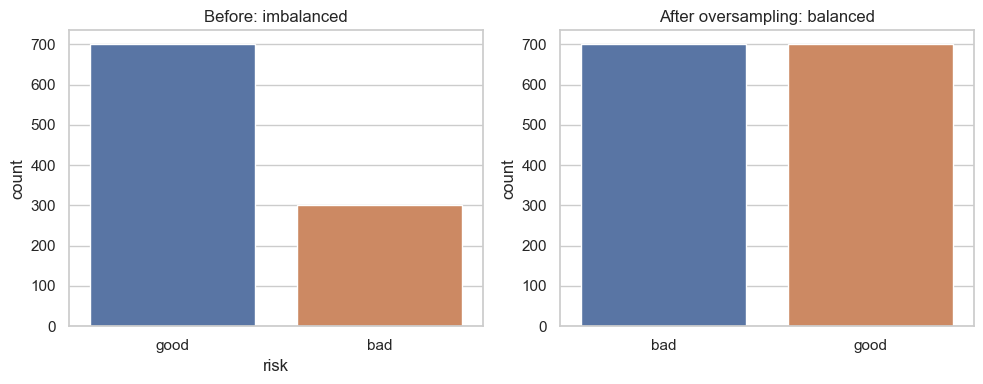

In [17]:
from sklearn.utils import resample

# imbalanced-learn is not needed: this helper reproduces RandomOverSampler using scikit-learn.
def random_oversample(X, y, random_state=0):
    """Oversample the minority class(es) up to the majority count.
    A drop-in for imbalanced-learn's RandomOverSampler, using sklearn.utils.resample."""
    X_arr, y_arr = np.asarray(X), np.asarray(y)
    counts = pd.Series(y_arr).value_counts()
    n_max = int(counts.max())
    px, py = [], []
    for cls in counts.index:
        idx = np.where(y_arr == cls)[0]
        keep = resample(idx, replace=True, n_samples=n_max, random_state=random_state)
        px.append(X_arr[keep]); py.append(y_arr[keep])
    Xr, yr = np.vstack(px), np.concatenate(py)
    order = resample(np.arange(len(yr)), replace=False, n_samples=len(yr), random_state=random_state)
    return Xr[order], yr[order]

X_imb = credit[['credit_amount', 'duration_months', 'age_years']]
y_imb = credit['risk']
print('Before:', Counter(y_imb))

X_bal, y_bal = random_oversample(X_imb, y_imb, random_state=0)
print('After oversampling:', Counter(y_bal))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_imb, ax=ax[0], hue=y_imb, legend=False); ax[0].set_title('Before: imbalanced')
sns.countplot(x=y_bal, ax=ax[1], hue=y_bal, legend=False); ax[1].set_title('After oversampling: balanced')
plt.tight_layout(); plt.show()

<a id="sec8"></a>
# Section 8: Splitting and preprocessing without leakage

**Definition:** data leakage is when information from the test set influences preprocessing, making validation results too optimistic.

**Example:** fitting a `StandardScaler` on the whole dataset means the test set's mean and range have secretly shaped the scaling.

**Analogy:** letting students see the exam answers while revising: their practice scores look great but mean nothing.

**Explanation:** the rule is simple. **Split first**, then **fit** every transformer on the **training set only**, and merely **apply** them to the test set.

In [18]:
from sklearn.model_selection import train_test_split

X = credit[['credit_amount', 'duration_months', 'age_years']]
y = (credit['risk'] == 'bad').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)   # split FIRST

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform only on test

print('Train shape:', X_train_scaled.shape, '| Test shape:', X_test_scaled.shape)
print('Train mean (~0):', X_train_scaled.mean(axis=0).round(2))
print('Test mean (not exactly 0, and that is correct):', X_test_scaled.mean(axis=0).round(2))

Train shape: (800, 3) | Test shape: (200, 3)
Train mean (~0): [-0.  0.  0.]
Test mean (not exactly 0, and that is correct): [ 0.12  0.14 -0.1 ]


<a id="sec9"></a>
# Section 9: Putting it together - a preprocessing Pipeline

**Definition:** a scikit-learn **Pipeline** chains preprocessing steps (and a model) into one object; a **ColumnTransformer** applies different steps to different columns.

**Example:** scale the numeric columns and one-hot encode the categorical columns in a single fitted object.

**Analogy:** a factory production line: raw data goes in one end and model-ready data comes out the other, identically every time.

**Explanation:** a Pipeline is the professional way to preprocess: it **guarantees no leakage** (everything is fitted on train when you call `fit`), keeps the steps together so they apply identically in production, and can be cross-validated as a unit.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric = ['credit_amount', 'duration_months', 'age_years']
categorical = ['checking_status', 'purpose', 'housing']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
])

X = credit[numeric + categorical]
y = (credit['risk'] == 'bad').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

X_train_ready = preprocess.fit_transform(X_train)   # fitted on train only
X_test_ready = preprocess.transform(X_test)
print('Model-ready train matrix shape:', X_train_ready.shape)
print('(numeric columns scaled + categorical columns one-hot expanded)')

Model-ready train matrix shape: (800, 20)
(numeric columns scaled + categorical columns one-hot expanded)


<a id="exercises"></a>
# Section 10: Exercises

These use the seaborn `tips` dataset (restaurant bills), a change from the credit data used in the examples.

### Exercise 1: Normalize vs standardize

Take `tips[['total_bill', 'tip', 'size']]`. Produce a Min-Max normalized version and a standardized version, and print the min/max of the normalized one and the mean of the standardized one.

In [20]:
# Your turn. Write your solution here:


In [21]:
# Coach answer
num = tips[['total_bill', 'tip', 'size']]
mm = MinMaxScaler().fit_transform(num)
ss = StandardScaler().fit_transform(num)
print(f'Normalized min/max: {mm.min():.2f} / {mm.max():.2f}')
print('Standardized means:', ss.mean(axis=0).round(3))

Normalized min/max: 0.00 / 1.00
Standardized means: [-0.  0. -0.]


### Exercise 2: Engineer and encode

Create a binned feature `bill_band` from `tips['total_bill']` (bins of your choice with `pd.cut`), then one-hot encode the `day` column with `pd.get_dummies`.

In [22]:
# Your turn. Write your solution here:


In [23]:
# Coach answer
tips['bill_band'] = pd.cut(tips['total_bill'], bins=[0, 15, 30, 60],
                          labels=['low', 'medium', 'high'])
day_oh = pd.get_dummies(tips['day'], prefix='day', dtype=int)
print('bill_band counts:', tips['bill_band'].value_counts().to_dict())
print('day one-hot columns:', day_oh.shape[1])

bill_band counts: {'medium': 132, 'low': 80, 'high': 32}
day one-hot columns: 4


### Exercise 3: Rebalance an imbalanced target

The tips `time` column (Lunch/Dinner) is imbalanced. Using `total_bill`, `tip`, `size` as features and `time` as the target, split into train/test (stratified) and oversample the **training** set with `RandomOverSampler`. Print the class balance before and after.

In [24]:
# Your turn. Write your solution here:


In [25]:
X = tips[['total_bill', 'tip', 'size']]
y = tips['time']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print('Train before:', Counter(y_tr))
X_bal, y_bal = random_oversample(X_tr, y_tr, random_state=0)
print('Train after :', Counter(y_bal))
print('(The test set is left untouched.)')

Train before: Counter({'Dinner': 141, 'Lunch': 54})
Train after : Counter({'Dinner': 141, 'Lunch': 141})
(The test set is left untouched.)


<a id="challenge"></a>
## Challenge (optional): a complete, leakage-safe pipeline on tips

Build a `ColumnTransformer` that standardizes the numeric `tips` features (`total_bill`, `tip`, `size`) and one-hot encodes the categorical ones (`sex`, `smoker`, `day`), to predict `time`. Split (stratified), fit on the **training** set only, transform both, and print the final shapes.

In [26]:
# Your turn. Write your solution here:


In [27]:
# Coach answer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric = ['total_bill', 'tip', 'size']
categorical = ['sex', 'smoker', 'day']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
])

X = tips[numeric + categorical]
y = tips['time']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)

X_train_ready = preprocess.fit_transform(X_train)   # fitted on train only
X_test_ready = preprocess.transform(X_test)
print('Train ready:', X_train_ready.shape)
print('Test ready :', X_test_ready.shape)
print('Numeric standardized, categorical one-hot expanded, no leakage.')

Train ready: (195, 11)
Test ready : (49, 11)
Numeric standardized, categorical one-hot expanded, no leakage.


<a id="takeaways"></a>
## Key Takeaways

| Concept / command | What it does |
|---|---|
| `SimpleImputer(strategy='mean')` | Fill missing numeric values (use `median` for skew) |
| `SimpleImputer(strategy='most_frequent')` | Fill missing categorical values with the mode |
| `MinMaxScaler` | Normalize each feature to 0-1 (bounded, outlier-sensitive) |
| `StandardScaler` | Standardize to mean 0, std 1 (the usual default) |
| `pd.cut`, `.dt`, ratios | Feature engineering: bins, date parts, combined features |
| `LabelEncoder` | Integer per category (invents an order; use with care) |
| `pd.get_dummies` / `OneHotEncoder` | 0/1 column per category (safe for nominal data) |
| `sklearn.utils.resample` (over/under-sample) | Rebalance an imbalanced target, train only (no extra library) |
| `train_test_split(..., stratify=y)` | Split before preprocessing; keep class ratios |
| Fit on train, transform on test | The rule that prevents data leakage |
| `Pipeline` + `ColumnTransformer` | Chain preprocessing safely and reproducibly |


## Conclusion

You can now take raw risk data and make it model-ready: impute numeric and categorical gaps, scale, engineer, encode and rebalance, all without leaking information from the test set, and wire it together in a Pipeline. The next notebooks use this prepared data to train and evaluate models.

<a id="reading"></a>
## Further Reading & Resources

- [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html) scalers, encoders and imputers.
- [scikit-learn: Pipelines and ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html) the leakage-safe way to combine steps.
- [scikit-learn: resample](https://scikit-learn.org/stable/modules/generated/sklearn.utils.resample.html) simple over- and under-sampling. (The optional [imbalanced-learn](https://imbalanced-learn.org/stable/) library adds SMOTE and more.)